Recurrent neural networks usually works on textual data

# <span style="color:#1B4F72;">Why Use RNN Instead of ANN?</span>

### <span style="color:#2980B9;">1. Variable Input Size :</span>

- In text and other sequential data, the **input sequence length can vary**.
- RNNs are designed to process sequences of different lengths, making them suitable for text and time-series data.

### <span style="color:#8E44AD;">2. Computational Power</span>

- Feeding very long sequences directly into an ANN can require **large computational resources**.
- RNNs process the sequence **step-by-step**, making sequential processing more practical.

### <span style="color:#16A085;">3. Semantic Meaning & Sequence</span>

- In sequential data, the **order and context of elements matter**.
- RNNs maintain a **hidden state**, allowing information from previous elements to influence the current output.

> **ANN → Processes inputs independently**  
> **RNN → Processes sequences + remembers previous information**

<mark> Data Feeding in Rnn

# <span style="color:#1B4F72;">How Data is Sent to an RNN?</span>

An RNN processes **sequential data one step at a time** while carrying information from previous time steps through its **hidden state**.

---

## <span style="color:#2980B9;">Example Dataset</span>

Suppose we have these reviews:

```text
1. movie was good  →  1
2. movie was bad   →  0
3. movie was not good →  0
```

Here:

```text
1 → Positive
0 → Negative
```

---

## <span style="color:#8E44AD;">Vocabulary</span>

First, we create a vocabulary containing all unique words:

```text
movie → 0
was   → 1
good  → 2
bad   → 3
not   → 4
```

So:

```text
Vocabulary Size = 5
```

---

## <span style="color:#16A085;">Convert Words into Numbers</span>

Each word can be represented using **One-Hot Encoding**.

```text
movie → [1,0,0,0,0]
was   → [0,1,0,0,0]
good  → [0,0,1,0,0]
bad   → [0,0,0,1,0]
not   → [0,0,0,0,1]
```

For:

```text
movie was good
```

we get:

```text
[
 [1,0,0,0,0],   ← movie
 [0,1,0,0,0],   ← was
 [0,0,1,0,0]    ← good
]
```

Therefore, its shape is:

```text
(3, 5)
```

> **3 = number of time steps**  
> **5 = number of input features / vocabulary size**

---

## <span style="color:#C0392B;">What is a Time Step?</span>

In an RNN, each word can be treated as one **time step**.

```text
movie → t₁
was   → t₂
good  → t₃
```

The words are **not sent all at once**.

They are processed sequentially:

```text
t₁              t₂              t₃
movie           was             good
  ↓              ↓               ↓
RNN ───────────→ RNN ──────────→ RNN
  ↓              ↓               ↓
h₁              h₂              h₃
```

At every step, the RNN receives:

```text
Current Input + Previous Hidden State
```

---

## <span style="color:#D35400;">How Information Flows</span>

At the first time step:

```text
movie
  ↓
RNN
  ↓
h₁
```

At the second time step:

```text
was + h₁
      ↓
     RNN
      ↓
     h₂
```

At the third time step:

```text
good + h₂
       ↓
      RNN
       ↓
      h₃
```

So the information flows like:

```text
Input₁ → RNN → h₁
                 ↓
Input₂ → RNN → h₂
                 ↓
Input₃ → RNN → h₃
```

> The **hidden state carries information from previous time steps**.

---

## <span style="color:#7D3C98;">For Sentiment Classification</span>

For a complete review:

```text
movie → was → good
  ↓      ↓      ↓
 RNN →  RNN →  RNN
  ↓      ↓      ↓
 h₁     h₂     h₃
               ↓
          Final Output
               ↓
          Sentiment = 1
```

The final hidden state contains information gathered from the sequence and can be used to make the final prediction.

```text
"movie was good"
        ↓
      RNN
        ↓
   Sentiment
        ↓
        1
```

---

## <span style="color:#2980B9;">Input Shape in PyTorch</span>

For an RNN, the input is generally represented as:

```text
(batch_size, sequence_length, input_size)
```

For example:

```text
(1, 3, 5)
```

means:

```text
1 → one review
3 → three time steps / words
5 → five input features
```

For multiple reviews:

```text
(batch_size, 3, 5)
```

Example:

```text
(3, 3, 5)
```

means:

```text
3 reviews
3 words per review
5 features per word
```

---

## <span style="color:#1B4F72;">Complete Flow</span>

```text
Raw Text
   ↓
Tokenization
   ↓
Vocabulary
   ↓
Numerical Representation
   ↓
Sequence
   ↓
(batch_size, seq_len, input_size)
   ↓
RNN processes one time step at a time
   ↓
Hidden State carries previous information
   ↓
Final Hidden State
   ↓
Output Layer
   ↓
Prediction
```

> **Core Idea:**  
> **RNN does not simply process all words independently. It processes the sequence step-by-step and carries information from previous steps through the hidden state.**

<mark> Rnn Architecture

ANN = Feed Forward Network

RNN = Feed Back Network

<B> Why ?

ANN is called Feed-Forward because information moves only in one direction: Input → Hidden Layers → Output.

RNN is called Recurrent because information from the previous timestep is fed back into the network through the hidden state, giving it a form of memory

> 🧠 **ANN vs RNN Parameters**

- **ANN:** 18 input→hidden weights + 4 biases/other parameters.
- **RNN:** Has additional **9 recurrent (feedback) weights** because the hidden state is connected back to the next timestep.

👉 **RNN has more parameters because of these recurrent connections.**

# <span style="color:#1B4F72;">ANN vs RNN — Major Differences</span>

There are **2 major differences** between ANN and RNN.

---

## <span style="color:#2980B9;">Difference 1: How Data is Processed</span>

### **ANN**

In ANN, we generally provide the **complete input at once** to the neural network.

```text
Complete Input
      ↓
Forward Propagation
      ↓
Output
      ↓
Backpropagation
      ↓
Update Weights
```

### **RNN**

In RNN, **sequential data is processed step-by-step (one time step at a time)**.

```text
Input₁ → RNN → Hidden State₁
                  ↓
Input₂ → RNN → Hidden State₂
                  ↓
Input₃ → RNN → Hidden State₃
                  ↓
                Output
```

The important difference is that the RNN passes the **hidden state from the previous time step** to the next time step.

> **ANN → Processes the input as a whole**  
> **RNN → Processes the sequence step-by-step + carries previous information**

## <span style="color:#8E44AD;">Difference 2: Data Flow & Hidden State</span>

### **ANN**

ANN does **not maintain a hidden state or memory** of previous inputs.

```text
Input → Neural Network → Output
```

Each input is processed independently.

### **RNN**

RNN maintains a **hidden state** that carries information from the previous time step.

```text
Input₁ → RNN → Hidden State₁
                  ↓
                  Input₂ → RNN → Hidden State₂
                                    ↓
                                    Input₃ → RNN → gHidden State₃
                                    ```

                                    The **previous hidden state is passed back into the RNN** along with the current input.

                                    > **ANN → No memory of previous inputs**  
                                    > **RNN → Hidden state carries information from previous time steps**

In [ ]:
# code implementation

import torch
import torch.nn as nn

In [ ]:
rnn = nn.RNN(
    input_size=5,
    hidden_size=3,
    batch_first=True
)

dense = nn.Linear(3, 1)

In [ ]:
print(rnn)
print(dense)

RNN(5, 3, batch_first=True)
Linear(in_features=3, out_features=1, bias=True)


In [ ]:
print(rnn.weight_ih_l0)
print(rnn.weight_hh_l0)

print(rnn.bias_ih_l0)
print(rnn.bias_hh_l0)

Parameter containing:
tensor([[-0.0661,  0.5665,  0.0545,  0.2985, -0.1518],
        [-0.2473, -0.3342,  0.3362,  0.1215, -0.2168],
        [-0.2525,  0.4912,  0.3189, -0.4775, -0.2597]], requires_grad=True)
Parameter containing:
tensor([[ 0.4381,  0.0563, -0.2373],
        [ 0.4333,  0.1396, -0.5544],
        [ 0.2284, -0.4140, -0.0513]], requires_grad=True)
Parameter containing:
tensor([-0.0431,  0.5729, -0.0537], requires_grad=True)
Parameter containing:
tensor([ 0.3997, -0.1912,  0.3877], requires_grad=True)


<b>we learned how we provide data to rnn and now we learn Forward Propagation inside rnn it means when we give inputs to rnn how does rnn calculates the output

Concpet used While FP in rnn : Unfolding thorough time

<b> <mark> Full Picture how rnn process data and find output (detailed )

🧠 RNN Forward Propagation — Sentiment Analysis Example

<div align="center">  🔄 RNN Forward Propagation

From Words → Vectors → Hidden States → Final Sentiment

</div>  
---

🎯 1. Objective

We will understand RNN forward propagation using a very small
sentiment-analysis dataset with only 4 sentences.

Our task:

> Given a movie review, predict whether it is Positive (1) or Negative (0).




---

📊 2. Sample Dataset

Review	Sentiment

good movie	1
bad movie	0
very good	1
very bad	0


For understanding the RNN, we will take only one review:

> "good movie"



So our sequence contains 2 time steps:

t = 1 → good  
t = 2 → movie  
  
  
---  
  
🧩 3. Convert Words into Vectors  
  
An RNN cannot directly understand words.  
  
So suppose we have already converted our words into simple vectors:  
  
good  → [1, 0, 1, 0, 0]  
movie → [0, 1, 0, 1, 0]  
  
Therefore:  
  
\[
X_1 =  
\begin{bmatrix}  
1\\  
0\\  
1\\  
0\\  
0  
\end{bmatrix}  
\]
  
\[
X_2 =  
\begin{bmatrix}  
0\\  
1\\  
0\\  
1\\  
0  
\end{bmatrix}  
\]
  
Important dimensions  
  
Input vector size = 5  
  
Therefore:  
  
\[
\boxed{input\_size = 5}  
\]
  
We have:  
  
Number of words = 2  
  
Therefore:  
  
\[
\boxed{sequence\ length = 2}  
\]
  
For this example, suppose:  
  
batch_size = 1  
  
Hence the input shape is:  
  
\[
\boxed{(batch\_size,\ sequence\_length,\ input\_size)}  
\]
  
\[
\boxed{(1,\ 2,\ 5)}  
\]
  
  
---  
  
🧠 4. RNN Architecture  
  
Suppose our RNN is:  
  
rnn = nn.RNN(  
    input_size=5,  
    hidden_size=3,  
    batch_first=True  
)  
  
dense = nn.Linear(3, 1)  
  
Therefore:  
  
Input size  = 5  
Hidden size = 3  
Output size = 1  
  
The RNN will create a hidden vector containing 3 values.  
  
  
---  
  
🔑 5. RNN Formula  
  
The basic RNN hidden-state equation is:  
  
\[
\boxed{  
h_t = f(W_{ih}x_t + b_{ih} + W_{hh}h_{t-1} + b_{hh})  
}  
\]
  
Where:  
  
Symbol  Meaning  
  
(x_t)   Current input  
(h_t)   Current hidden state  
(h_{t-1})   Previous hidden state  
(W_{ih})    Input → Hidden weights  
(W_{hh})    Hidden → Hidden weights  
(b_{ih})    Input → Hidden bias  
(b_{hh})    Hidden → Hidden bias  
(f) Activation function  
  
  
Usually, for a simple RNN:  
  
\[
f = \tanh  
\]
  
So:  
  
\[
\boxed{  
h_t =  
\tanh(W_{ih}x_t+b_{ih}+W_{hh}h_{t-1}+b_{hh})  
}  
\]
  
  
---  
  
⏱️ 6. Time Step 1 — Word = "good"  
  
Our first word is:  
  
\[
X_1 =  
\begin{bmatrix}  
1\\  
0\\  
1\\  
0\\  
0  
\end{bmatrix}  
\]
  
At the beginning, there is no previous hidden state.  
  
Therefore we initialize:  
  
\[
\boxed{  
h_0 =  
\begin{bmatrix}  
0\\  
0\\  
0  
\end{bmatrix}  
}  
\]
  
So:  
  
Previous hidden state  
        ↓  
h₀ = [0, 0, 0]  
  
  
---  
  
⚙️ 7. Assume Some Weights  
  
To make the calculation easy, let's use small illustrative weights.  
  
Input → Hidden weights  
  
\[
W_{ih} =  
\begin{bmatrix}  
0.2 & 0.1 & 0.3 & 0.1 & 0.2\\  
0.1 & 0.3 & 0.2 & 0.2 & 0.1\\  
0.3 & 0.2 & 0.1 & 0.1 & 0.2  
\end{bmatrix}  
\]
  
Shape:  
  
\[
\boxed{W_{ih}=(3,5)}  
\]
  
Why?  
  
hidden_size × input_size  
= 3 × 5  
  
  
---  
  
Hidden → Hidden weights  
  
\[
W_{hh} =  
\begin{bmatrix}  
0.1 & 0.2 & 0.1\\  
0.2 & 0.1 & 0.2\\  
0.1 & 0.1 & 0.2  
\end{bmatrix}  
\]
  
Shape:  
  
\[
\boxed{W_{hh}=(3,3)}  
\]
  
  
---  
  
Biases  
  
For simplicity:  
  
\[
b_{ih} =  
\begin{bmatrix}  
0\\  
0\\  
0  
\end{bmatrix}  
\]
  
\[
b_{hh} =  
\begin{bmatrix}  
0\\  
0\\  
0  
\end{bmatrix}  
\]
  
  
---  
  
🧮 8. Calculate Time Step 1  
  
Formula:  
  
\[
h_1 =  
\tanh(W_{ih}X_1+b_{ih}+W_{hh}h_0+b_{hh})  
\]
  
Since:  
  
\[
h_0=[0,0,0]^T  
\]
  
we get:  
  
\[
W_{hh}h_0=0  
\]
  
Therefore:  
  
\[
h_1=\tanh(W_{ih}X_1)  
\]
  
Now:  
  
\[
W_{ih}X_1  
=  
\begin{bmatrix}  
0.2 & 0.1 & 0.3 & 0.1 & 0.2\\  
0.1 & 0.3 & 0.2 & 0.2 & 0.1\\  
0.3 & 0.2 & 0.1 & 0.1 & 0.2  
\end{bmatrix}  
\begin{bmatrix}  
1\\  
0\\  
1\\  
0\\  
0  
\end{bmatrix}  
\]
  
Calculate each value:  
  
\[
0.2(1)+0.1(0)+0.3(1)+0.1(0)+0.2(0)  
=0.5  
\]
  
\[
0.1(1)+0.3(0)+0.2(1)+0.2(0)+0.1(0)  
=0.3  
\]
  
\[
0.3(1)+0.2(0)+0.1(1)+0.1(0)+0.2(0)  
=0.4  
\]
  
Therefore:  
  
\[
W_{ih}X_1=  
\begin{bmatrix}  
0.5\\  
0.3\\  
0.4  
\end{bmatrix}  
\]
  
Apply tanh:  
  
\[
h_1=  
\tanh  
\begin{bmatrix}  
0.5\\  
0.3\\  
0.4  
\end{bmatrix}  
\]
  
Approximately:  
  
\[
\boxed{  
h_1\approx  
\begin{bmatrix}  
0.462\\  
0.291\\  
0.380  
\end{bmatrix}  
}  
\]
  
  
---  
  
🔄 9. Time Step 2 — Word = "movie"  
  
Now we send the second word.  
  
\[
X_2=  
\begin{bmatrix}  
0\\  
1\\  
0\\  
1\\  
0  
\end{bmatrix}  
\]
  
But this time something important happens.  
  
We have a previous hidden state:  
  
\[
h_1=  
\begin{bmatrix}  
0.462\\  
0.291\\  
0.380  
\end{bmatrix}  
\]
  
Therefore the RNN receives TWO pieces of information:  
  
┌──────────────┐  
X₂ = "movie" ───►│              │  
                 │     RNN      │───► h₂  
h₁ ─────────────►│              │  
                 └──────────────┘  
  
This is the fundamental idea of an RNN:  
  
> Current input + previous hidden state → current hidden state  
  
  
  
  
---  
  
🧮 10. Calculate Time Step 2  
  
Formula:  
  
\[
\boxed{  
h_2=  
\tanh(W_{ih}X_2+b_{ih}+W_{hh}h_1+b_{hh})  
}  
\]
  
Let's calculate the two major components separately.  
  
  
---  
  
Part A — Current Word  
  
\[
W_{ih}X_2  
\]
  
\[
=  
\begin{bmatrix}  
0.2 & 0.1 & 0.3 & 0.1 & 0.2\\  
0.1 & 0.3 & 0.2 & 0.2 & 0.1\\  
0.3 & 0.2 & 0.1 & 0.1 & 0.2  
\end{bmatrix}  
\begin{bmatrix}  
0\\  
1\\  
0\\  
1\\  
0  
\end{bmatrix}  
\]
  
First neuron:  
  
\[
0.1+0.1=0.2  
\]
  
Second neuron:  
  
\[
0.3+0.2=0.5  
\]
  
Third neuron:  
  
\[
0.2+0.1=0.3  
\]
  
Therefore:  
  
\[
W_{ih}X_2=  
\begin{bmatrix}  
0.2\\  
0.5\\  
0.3  
\end{bmatrix}  
\]
  
  
---  
  
🧮 11. Previous Information  
  
Now calculate:  
  
\[
W_{hh}h_1  
\]
  
\[
=  
\begin{bmatrix}  
0.1 & 0.2 & 0.1\\  
0.2 & 0.1 & 0.2\\  
0.1 & 0.1 & 0.2  
\end{bmatrix}  
\begin{bmatrix}  
0.462\\  
0.291\\  
0.380  
\end{bmatrix}  
\]
  
Approximately:  
  
\[
W_{hh}h_1  
\approx  
\begin{bmatrix}  
0.143\\  
0.225\\  
0.151  
\end{bmatrix}  
\]
  
  
---  
  
➕ 12. Combine Current + Previous Information  
  
Now:  
  
\[
W_{ih}X_2 + W_{hh}h_1  
\]
  
\[
=  
\begin{bmatrix}  
0.2\\  
0.5\\  
0.3  
\end{bmatrix}  
+  
\begin{bmatrix}  
0.143\\  
0.225\\  
0.151  
\end{bmatrix}  
\]
  
\[
=  
\begin{bmatrix}  
0.343\\  
0.725\\  
0.451  
\end{bmatrix}  
\]
  
Now apply tanh:  
  
\[
h_2=  
\tanh  
\begin{bmatrix}  
0.343\\  
0.725\\  
0.451  
\end{bmatrix}  
\]
  
Approximately:  
  
\[
\boxed{  
h_2\approx  
\begin{bmatrix}  
0.330\\  
0.620\\  
0.423  
\end{bmatrix}  
}  
\]
  
  
---  
  
🧠 13. What Just Happened?  
  
This is the most important part.  
  
At:  
  
⏱️ T = 1  
  
good  
 ↓  
X₁  
 ↓  
RNN  
 ↓  
h₁  
  
There was no previous information, so:  
  
\[
h_0=0  
\]
  
  
---  
  
⏱️ T = 2  
  
movie ──────► X₂  
                │  
                ▼  
              ┌─────┐  
h₁ ──────────►│ RNN │  
              └─────┘  
                │  
                ▼  
               h₂  
  
Now:  
  
\[
\boxed{  
h_2=f(X_2,h_1)  
}  
\]
  
So (h_2) contains information from:  
  
"good"  
   +  
"movie"  
  
This is how the RNN processes sequence information.  
  
  
---  
  
🔁 14. Unfolding Through Time  
  
The RNN can be visualized as:  
  
┌─────────┐  
X₁ ─────────►│   RNN   │  
             └────┬────┘  
                  │  
                 h₁  
                  │  
                  ▼  
             ┌─────────┐  
X₂ ─────────►│   RNN   │  
             └────┬────┘  
                  │  
                 h₂  
                  │  
                  ▼  
             ┌─────────┐  
X₃ ─────────►│   RNN   │  
             └────┬────┘  
                  │  
                 h₃  
  
This representation is called:  
  
\[
\boxed{\text{Unfolding Through Time}}  
\]
  
⚠️ Important  
  
These are NOT different RNN layers.  
  
They are the same RNN cell reused at different time steps.  
  
Therefore:  
  
\[
\boxed{\text{Same weights are reused at every time step}}  
\]
  
This is called:  
  
\[
\boxed{\text{Parameter Sharing / Weight Sharing}}  
\]
  
  
---  
  
📐 15. Complete RNN Forward Pass  
  
For a sequence:  
  
\[
X_1,X_2,\ldots,X_T  
\]
  
the RNN performs:  
  
\[
\boxed{  
h_1=f(W_{ih}X_1+W_{hh}h_0+b)  
}  
\]
  
\[
\boxed{  
h_2=f(W_{ih}X_2+W_{hh}h_1+b)  
}  
\]
  
\[
\boxed{  
h_3=f(W_{ih}X_3+W_{hh}h_2+b)  
}  
\]
  
and so on:  
  
\[
\boxed{  
h_t=f(W_{ih}X_t+W_{hh}h_{t-1}+b)  
}  
\]
  
  
---  
  
🎯 16. From Hidden State to Sentiment  
  
After processing the complete sentence, we can use the last hidden state:  
  
\[
h_2  
\]
  
to predict sentiment.  
  
Our dense layer is:  
  
dense = nn.Linear(3, 1)  
  
Therefore:  
  
\[
\boxed{  
y_{raw}=W_yh_2+b_y  
}  
\]
  
Here:  
  
h₂ → 3 values  
     ↓  
Linear Layer  
     ↓  
1 value  
  
Suppose:  
  
\[
W_y=  
\begin{bmatrix}  
0.5 & 0.8 & 0.2  
\end{bmatrix}  
\]
  
and:  
  
\[
b_y=0.1  
\]
  
Then:  
  
\[
y_{raw}  
=  
0.5(0.330)+0.8(0.620)+0.2(0.423)+0.1  
\]
  
\[
y_{raw}\approx0.706  
\]
  
This raw value is called a logit.  
  
  
---  
  
🔢 17. Convert Logit to Probability  
  
For binary sentiment classification, we can use the sigmoid function:  
  
\[
\boxed{  
\sigma(z)=\frac{1}{1+e^{-z}}  
}  
\]
  
Therefore:  
  
\[
P(\text{Positive})  
=  
\sigma(0.706)  
\]
  
\[
\boxed{  
P(\text{Positive})\approx0.67  
}  
\]
  
So:  
  
Positive probability ≈ 67%  
Negative probability ≈ 33%  
  
Using a threshold of 0.5:  
  
\[
P(\text{Positive})>0.5  
\]
  
Therefore:  
  
\[
\boxed{\text{Prediction = Positive}}  
\]
  
  
---  
  
🧠 18. Complete Flow  
  
<div align="center">"good movie"  
      │  
      ▼  
Tokenization  
      │  
      ▼  
Word → Vector  
      │  
      ├───────────────┐  
      ▼               │  
   X₁ = good          │  
      │               │  
      ▼               │  
    RNN                │  
      │               │  
      ▼               │  
     h₁ ──────────────┤  
                      │  
                      ▼  
   X₂ = movie ──────► RNN  
                      │  
                      ▼  
                     h₂  
                      │  
                      ▼  
                  Linear Layer  
                      │  
                      ▼  
                    Logit  
                      │  
                      ▼  
                   Sigmoid  
                      │  
                      ▼  
              Positive / Negative  
  
</div>  
---  
  
📦 19. Dimensions at Every Step  
  
For our example:  
  
batch_size   = 1  
sequence_len = 2  
input_size   = 5  
hidden_size  = 3  
output_size  = 1  
  
Input:  
  
\[
X=(1,2,5)  
\]
  
At each time step:  
  
\[
X_t=(1,5)  
\]
  
Hidden state:  
  
\[
h_t=(1,3)  
\]
  
Final hidden state:  
  
\[
h_2=(1,3)  
\]
  
Linear layer:  
  
\[
(1,3)\rightarrow(1,1)  
\]
  
Final output:  
  
\[
\boxed{(1,1)}  
\]
  
  
---  
  
🔥 20. The Core Concept to Remember  
  
The entire RNN forward propagation can be reduced to this:  
  
\[
\boxed{  
\text{Current Input}  
+  
\text{Previous Hidden State}  
\rightarrow  
\text{Current Hidden State}  
}  
\]
  
Mathematically:  
  
\[
\boxed{  
h_t=  
\tanh  
\left(  
W_{ih}x_t+  
W_{hh}h_{t-1}+  
b  
\right)  
}  
\]
  
For our sentence:  
  
\[
\boxed{  
h_1=f(X_1,h_0)  
}  
\]
  
\[
\boxed{  
h_2=f(X_2,h_1)  
}  
\]
  
Therefore:  
  
\[
\boxed{  
h_2\text{ contains information from }X_1\text{ and }X_2  
}  
\]
  
And that is the fundamental reason we use an RNN for sequential data. 🔄🧠  
  
  
---  
  
⭐ One-Line Mental Model  
  
> RNN = Read the current word + remember information from previous words → create a new memory (hidden state).  
  
  
  
Word₁ → h₁  
         ↓  
Word₂ + h₁ → h₂  
              ↓  
Word₃ + h₂ → h₃  
              ↓  
             ...  
              ↓  
       Final Hidden State  
              ↓  
          Prediction  
  
  
Wrote this same as it is so that the formaulas and all can render on Google Collab while written in .md

In [ ]:
import torch
import torch.nn as nn

In [ ]:
sentences = [
    "I love this product",
    "This movie made me smile",
    "Service was friendly and quick",
    "Today felt bright and happy",
    "This is the best day",
    "Absolutely fantastic experience",
    "I enjoyed every single moment",
    "Great job, well done",
    "The food tasted delicious",
    "Totally recommend to everyone",
    "Very satisfied with results",
    "This worked better than expected",
    "Amazing quality and value",
    "Such a pleasant surprise",
    "I feel positive about this",
    "I hate this product",
    "This movie bored me",
    "Service was rude and slow",
    "Today was cold and lonely",
    "This is the worst day",
    "Terrible experience overall",
    "I regret buying this",
    "Very disappointed with results",
    "The food tasted awful",
    "Do not recommend this",
    "It broke after one use",
    "Not worth the money",
    "Utterly frustrating and annoying",
    "I feel negative about this",
    "Such a waste of time",
]

labels = [1] * 15 + [0] * 15
labels = torch.tensor(labels, dtype=torch.float32)

In [ ]:
len(sentences)

30

In [ ]:
labels

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

<b> When we use small dataset we usually use Rnn but once we get a larger dataset we use LSTM for better performance

In [ ]:
# to send sentences into Rnn we need to tokenize and embedd them and convert them into numbers

import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence

In [ ]:
from collections import Counter

word_counts = Counter(
    word
    for sentence in sentences
    for word in sentence.lower().split()
)

word_to_idx = {
    word: i + 2
    for i, (word, _) in enumerate(word_counts.items())
}

word_to_idx["<OOV>"] = 1

vocab_size = max(word_to_idx.values()) + 1

In [ ]:
from torch.nn.utils.rnn import pad_sequence

seqs = [
    torch.tensor([word_to_idx.get(w, 1) for w in s.lower().split()])
    for s in sentences
]

max_len = max(len(s) for s in seqs)

X = pad_sequence(
    seqs,
    batch_first=True,
    padding_value=0
)

y = labels


                CURRENT WORK
                       │
                       ▼
              📝 Raw sentences
                       │
                       ▼
              🔤 Tokenization
                       │
                       ▼
              📖 Vocabulary
                       │
                       ▼
             🔢 Word → Integer ID
                       │
                       ▼
              📏 Sequence creation
                       │
                       ▼
                 Padding
                       │
                       ▼
                  X and y
                       │
                       ▼
              ⬇️ NEXT STEP ⬇️
                  Embedding
                       │
                       ▼
                    RNN
                       │
                       ▼
                  Linear
                       │
                       ▼
             Positive / Negative

In [ ]:
X.shape

torch.Size([30, 5])

In [ ]:
X[0]

tensor([2, 3, 4, 5, 0])

In [ ]:
from collections import Counter

nums = [1, 2, 2, 3, 3, 3]

c = Counter(nums)

print(c)

# Counter({3: 3, 2: 2, 1: 1})

Counter({3: 3, 2: 2, 1: 1})


In [ ]:
word_to_idx["i"]
print(word_to_idx["i"])
print(word_to_idx["love"])
print(word_to_idx["this"])
print(word_to_idx["product"])

2
3
4
5


In [ ]:
max_len

5

In [ ]:
#lets check vocab size

vocab_size = len(word_to_idx)

vocab_size

87

#till now we only tokenize our sentences now we will create embeddings of the words so we can provide it to the model

In [ ]:
# embeddings+ rnn setting

embedding_dim = 16
rnn_units = 8

In [ ]:
inp = X

In [ ]:
vocab_size = max(word_to_idx.values()) + 1

embedding = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=embedding_dim,
    padding_idx=0
)

rnn = nn.RNN(
    input_size=embedding_dim,
    hidden_size=rnn_units,
    batch_first=True
)

x = embedding(inp)

out, hidden = rnn(x)

x_last = hidden[-1]

out = nn.Linear(rnn_units, 1)(x_last)

out = torch.sigmoid(out)

In [ ]:
class SentimentRNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim=16, rnn_units=8):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=rnn_units,
            batch_first=True
        )

        self.fc = nn.Linear(rnn_units, 1)

    def forward(self, x):

        x = self.embedding(x)

        out, hidden = self.rnn(x)

        x_last = hidden[-1]

        out = self.fc(x_last)

        return torch.sigmoid(out)

In [ ]:
model = SentimentRNN(
    vocab_size=vocab_size,
    embedding_dim=16,
    rnn_units=8
)

In [ ]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(25):

    # Forward pass
    output = model(X)

    # Calculate loss
    loss = criterion(output.squeeze(), y)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/25 - Loss: {loss.item():.4f}")

Epoch 1/25 - Loss: 0.7123
Epoch 2/25 - Loss: 0.7099
Epoch 3/25 - Loss: 0.7074
Epoch 4/25 - Loss: 0.7051
Epoch 5/25 - Loss: 0.7027
Epoch 6/25 - Loss: 0.7003
Epoch 7/25 - Loss: 0.6980
Epoch 8/25 - Loss: 0.6957
Epoch 9/25 - Loss: 0.6935
Epoch 10/25 - Loss: 0.6912
Epoch 11/25 - Loss: 0.6890
Epoch 12/25 - Loss: 0.6868
Epoch 13/25 - Loss: 0.6847
Epoch 14/25 - Loss: 0.6825
Epoch 15/25 - Loss: 0.6804
Epoch 16/25 - Loss: 0.6783
Epoch 17/25 - Loss: 0.6762
Epoch 18/25 - Loss: 0.6741
Epoch 19/25 - Loss: 0.6720
Epoch 20/25 - Loss: 0.6700
Epoch 21/25 - Loss: 0.6679
Epoch 22/25 - Loss: 0.6659
Epoch 23/25 - Loss: 0.6639
Epoch 24/25 - Loss: 0.6619
Epoch 25/25 - Loss: 0.6599


<mark><b> Problem and Solutions with RNN

# <span style="color:#1B4F72;">Problems with RNN</span>

### <span style="color:#C0392B;">1. Long-Term Memory is Weak</span>

RNNs struggle to **remember information from very far back in a sequence**.

> Important information from earlier time steps may gradually be lost.

---

### <span style="color:#8E44AD;">2. Vanishing Gradient Problem</span>

During backpropagation, gradients can become **extremely small** as they travel through many time steps.

> Small gradients → **Weights learn very slowly** → Long-term dependencies become difficult to learn.

---

### <span style="color:#D35400;">3. Exploding Gradient</span>

Gradients can sometimes become **extremely large** during training.

> Very large gradients → **Unstable training** → Weights can change dramatically.

---

### <span style="color:#2980B9;">4. Long Dependencies Are Not Captured</span>

Basic RNNs have difficulty learning relationships between words or data points that are **far apart in a sequence**.

```text
Word₁ ── Word₂ ── Word₃ ── ... ── Word₁₀₀
  ↑                                  ↑
Important information          Difficult to connect
```

---

### <span style="color:#16A085;">5. Sequential Processing</span>

RNNs process sequence elements **one after another**, so the computations cannot be fully parallelized.

> This can make RNNs **slower to train** compared with architectures that process tokens more efficiently in parallel.

<b> That's why we use LSTM and GRU


<h2 style="
background: linear-gradient(135deg, #E8F8F5, #A3E4D7, #D1F2EB);
color: #0E6251;
padding: 14px 20px;
border-left: 6px solid #16A085;
border-radius: 10px;
font-weight: 800;
box-shadow: 0 4px 12px rgba(22,160,133,0.2);
">
LSTM — Long Short-Term Memory
</h2>

# RNN vs LSTM vs GRU

| Feature | RNN | LSTM | GRU |
|---|---|---|---|
| Full Form | Recurrent Neural Network | Long Short-Term Memory | Gated Recurrent Unit |
| Memory | Short-term | Short + Long-term | Short + Long-term |
| Gates | ❌ No | ✅ 3 Gates | ✅ 2 Gates |
| Cell State | ❌ No | ✅ Yes | ❌ No |
| Hidden State | ✅ Yes | ✅ Yes | ✅ Yes |
| Vanishing Gradient | 🔴 High | 🟢 Much lower | 🟢 Much lower |
| Parameters | 🟢 Fewest | 🔴 Most | 🟡 Fewer than LSTM |
| Training Speed | 🟢 Fastest | 🔴 Slowest | 🟢 Faster than LSTM |
| Complexity | 🟢 Simple | 🔴 Complex | 🟡 Moderate |

---

## 🧠 1. RNN

**Basic idea:**

> Current output depends on the **current input + previous hidden state**.

$$
h_t = \tanh(W_xx_t + W_hh_{t-1} + b)
$$

RNN mainly maintains information through its **hidden state**.

### ❌ Problem
For long sequences, old information gradually gets lost due to the **vanishing gradient problem**.

**Example:**

`I → went → to → the → ... → bank`

After many time steps, a basic RNN may struggle to remember information from the beginning.

---

## 🧠 2. LSTM

LSTM was designed to solve the long-term memory problem of RNN.

It has **two states**:

- `hₜ` → Hidden State
- `Cₜ` → Cell State (**long-term memory**)

### 🚪 3 Gates

| Gate | Purpose |
|---|---|
| Forget Gate | 🗑️ Decides what to remove |
| Input Gate | ➕ Decides what new information to store |
| Output Gate | 📤 Decides what to output |

So:

> **LSTM = RNN + controlled memory using gates**

Its cell state provides a path through which information can be carried across many time steps.

---

## 🧠 3. GRU

GRU is a **simplified version of LSTM**.

It uses only:

### 🚪 2 Gates

| Gate | Purpose |
|---|---|
| Update Gate | 🔄 Controls how much old/new information to keep |
| Reset Gate | ♻️ Controls how much previous information to forget |

GRU has:

- ❌ No separate cell state
- ✅ Only hidden state

So:

> **GRU = simpler gated RNN**

---

# 🔥 Main Difference

```text
RNN
 │
 ├── Hidden State
 └── No Gates
       ↓
   Short-term memory
       
       
LSTM
 │
 ├── Hidden State
 ├── Cell State
 └── 3 Gates
       ↓
   Better long-term memory
       
       
GRU
 │
 ├── Hidden State
 └── 2 Gates
       ↓
   Long-term memory with simpler architecture

<b> Understanding Gates of LSTM 

### <span style="color:#2980B9;">LSTM States</span>

**C<sub>t-1</sub> — Previous Cell State**

The previous cell state carries important information through the sequence and acts as the **long-term memory** of the LSTM.

> It allows the LSTM to preserve useful information for a longer period of time.

**H<sub>t-1</sub> — Previous Hidden State**

The previous hidden state carries information from the previous time step and represents the **short-term memory** of the LSTM.

> It is also used along with the current input to determine what information should be processed at the current step.

### <span style="color:#8E44AD;">In Short</span>

**C<sub>t-1</sub> → Long-Term Memory → Carries information across many time steps**

**H<sub>t-1</sub> → Short-Term Memory → Carries information from the previous step**

### <span style="color:#2980B9;">LSTM States & Inputs</span>

**X<sub>t</sub> — Current Input**

The current input is the **new information entering the LSTM at the current time step**.

> Example: In a sentence, **X<sub>t</sub>** can represent the current word/vector being processed.

---

**C<sub>t-1</sub> — Previous Cell State**

The previous cell state carries important information through the sequence and acts as the **long-term memory** of the LSTM.

> It helps preserve useful information across many time steps.

---

**H<sub>t-1</sub> — Previous Hidden State**

The previous hidden state carries information from the **previous time step** and acts as the **short-term memory**.

> It is combined with X<sub>t</sub> to process the current time step.

---

**C<sub>t</sub> — Current Cell State**

The current cell state is the **updated long-term memory** after the LSTM decides what information to keep, remove, and add.

---

**H<sub>t</sub> — Current Hidden State**

The current hidden state is the **updated short-term/output information** produced at the current time step.

> H<sub>t</sub> is also passed to the **next time step**.

### <span style="color:#8E44AD;">Overall Flow</span>

```text
          Xₜ
          ↓
Cₜ₋₁ →  LSTM  → Cₜ
          ↓
Hₜ₋₁ →       → Hₜ
```

> **X<sub>t</sub> → Current Input**  
> **C<sub>t-1</sub> → Previous Long-Term Memory**  
> **H<sub>t-1</sub> → Previous Short-Term Memory**  
> **C<sub>t</sub> → Updated Long-Term Memory**  
> **H<sub>t</sub> → Updated Short-Term Memory / Output**

> <mark>Why are Hidden State and Cell State the same size?</mark>

In an LSTM:

- **Hidden state (hₜ)** → short-term / output information
- **Cell state (cₜ)** → long-term memory

Both have shape:

**(batch_size, hidden_size)**

For example:

```text
batch_size = 32
hidden_size = 128

hₜ → (32, 128)
cₜ → (32, 128)

<mark><b> Gates of Lstm

# 🧠 LSTM — Forget Gate

---

## 🔹 1. What is the Forget Gate?

The **Forget Gate** decides:

> 🟡 **What information from the previous cell state should be REMEMBERED, and what should be FORGOTTEN?**

It looks at:

- **Previous hidden state** → $h_{t-1}$
- **Current input** → $x_t$

and produces a value between **0 and 1** for each element of the previous cell state.

---

## 🔹 2. Formula

$$
\boxed{
f_t = \sigma(W_f[h_{t-1},x_t] + b_f)
}
$$

### Where:

| Symbol | Meaning |
|---|---|
| $f_t$ | <mark><b>Forget Gate output</b></mark> |
| $h_{t-1}$ | Previous hidden state |
| $x_t$ | Current input |
| $W_f$ | <mark><b>Forget Gate weights</b></mark> |
| $b_f$ | Forget Gate bias |
| $\sigma$ | <mark><b>Sigmoid activation function</b></mark> |

---

## 🔹 3. Why Sigmoid?

The sigmoid function produces values between **0 and 1**:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

Therefore:

$$
0 \leq f_t \leq 1
$$

These values act like a **filter**.

### 🚦 Interpretation

| Value | Meaning |
|---|---|
| $0$ | ❌ <b>Completely forget</b> |
| $0.5$ | 🟡 Partially remember |
| $1$ | 🟢 <b>Completely remember</b> |

So the Forget Gate essentially asks:

> **"How much of the old memory should I keep?"**

---

## 🔹 4. How Does It Work?

Suppose the previous cell state is:

$$
C_{t-1}
$$

The Forget Gate generates:

$$
f_t
$$

Then they are multiplied element-by-element:

$$
\boxed{
f_t \odot C_{t-1}
}
$$

where $\odot$ means **element-wise multiplication**.

---

## 🔹 5. Simple Example

Suppose:

$$
C_{t-1}
=
[10,\;5,\;2]
$$

and the Forget Gate produces:

$$
f_t
=
[1,\;0.5,\;0]
$$

Then:

$$
f_t \odot C_{t-1}
$$

becomes:

$$
[1,0.5,0]
\odot
[10,5,2]
$$

$$
=
[10,\;2.5,\;0]
$$

### Therefore:

- **10 × 1 = 10** → 🟢 Keep completely
- **5 × 0.5 = 2.5** → 🟡 Keep partially
- **2 × 0 = 0** → 🔴 Forget completely

---

## 🔹 6. Complete Flow

$$
\boxed{
[h_{t-1},x_t]
\rightarrow
W_f[h_{t-1},x_t]+b_f
\rightarrow
\sigma
\rightarrow
f_t
}
$$

Then:

$$
\boxed{
f_t \odot C_{t-1}
}
$$

So:

> <mark><b>Forget Gate → decides how much old memory ($C_{t-1}$) to keep.</b></mark>

---

## 🔥 Most Important Point

<mark><b>Forget Gate does NOT directly delete the cell state.</b></mark>

Instead, it creates a **0–1 filter** and multiplies it with the previous cell state.

$$
\boxed{
\text{Old Memory}
\times
\text{Forget Gate}
=
\text{Filtered Old Memory}
}
$$

---

### 🧠 One-Line Memory Trick

> **Forget Gate = "How much of the OLD memory should I keep?"**

## 🟢 LSTM Input Gate

### 🔵 Candidate Cell State ($\tilde{C}_t$)

$\tilde{C}_t$ = **candidate state**

> It creates the **NEW information** that could potentially be added to the cell state.

$$
\tilde{C}_t =
\tanh(W_c[h_{t-1},x_t]+b_c)
$$

❌ It does **not** filter the Forget Gate's information.

---

### 🟢 Input Gate ($i_t$)

$i_t$ = **filter that decides HOW MUCH of the candidate information should be added.**

It uses the **Sigmoid activation function**:

$$
i_t =
\sigma(W_i[h_{t-1},x_t]+b_i)
$$

Since sigmoid gives values between **0 and 1**:

$$
0 \leq i_t \leq 1
$$

---

### 🔥 Easy Way to Remember

$$
\boxed{
\tilde{C}_t = \text{WHAT to add}
}
$$

$$
\boxed{
i_t = \text{HOW MUCH to add}
}
$$

Then:

$$
\boxed{
i_t\odot\tilde{C}_t
=
\text{NEW information actually added}
}
$$

### 🧠 Think of it like this:

**Candidate State** → "Here is some new information."

**Input Gate** → "Okay, I'll allow **this much** of it."

**Cell State** → "I'll add that amount to my memory."

# 🧠 LSTM — Input Gate

---

## 🔹 2. What is the Input Gate?

The **Input Gate** decides:

> 🟢 **What NEW information should be added to the cell state (memory)?**

The Input Gate uses:

- **Previous hidden state** → $h_{t-1}$
- **Current input** → $x_t$

It has **two parts**:

1. **Input Gate** → decides **how much new information to add**
2. **Candidate Cell State** → creates the **new information** that could be added

---

# 🔹 1. Input Gate

The Input Gate uses **Sigmoid**:

$$
\boxed{
i_t = \sigma(W_i[h_{t-1},x_t]+b_i)
}
$$

### Where:

| Symbol | Meaning |
|---|---|
| $i_t$ | <mark><b>Input Gate output</b></mark> |
| $h_{t-1}$ | Previous hidden state |
| $x_t$ | Current input |
| $W_i$ | <mark><b>Input Gate weights</b></mark> |
| $b_i$ | Input Gate bias |
| $\sigma$ | <mark><b>Sigmoid activation</b></mark> |

The output is between **0 and 1**:

$$
0 \leq i_t \leq 1
$$

### 🚦 Meaning

| Value | Meaning |
|---|---|
| $0$ | ❌ Don't add |
| $0.5$ | 🟡 Add partially |
| $1$ | 🟢 Add completely |

So the Input Gate asks:

> **"How much of the new information should I allow into memory?"**

---

# 🔹 2. Candidate Cell State

But the Input Gate alone doesn't create the new information.

We also calculate a **Candidate Cell State**:

$$
\boxed{
\tilde{C}_t
=
\tanh(W_c[h_{t-1},x_t]+b_c)
}
$$

### Why `tanh`?

`tanh` produces values between:

$$
-1 \leq \tilde{C}_t \leq 1
$$

So the candidate represents:

> 🔵 **The NEW information that could potentially be stored in memory.**

---

# 🔹 3. Input Gate + Candidate

Now we combine them:

$$
\boxed{
i_t \odot \tilde{C}_t
}
$$

Where:

- $i_t$ → **how much to add**
- $\tilde{C}_t$ → **what to add**

---

## 🔹 Example

Suppose:

$$
i_t=[0.8,\;0.2,\;1]
$$

and:

$$
\tilde{C}_t=[0.5,\;0.7,\;-0.4]
$$

Then:

$$
i_t\odot\tilde{C}_t
$$

$$
=
[0.8,0.2,1]
\odot
[0.5,0.7,-0.4]
$$

$$
=
[0.4,\;0.14,\;-0.4]
$$

### Meaning:

- **0.8 × 0.5 = 0.4** → 🟢 Most of the information is added
- **0.2 × 0.7 = 0.14** → 🟡 Only a small amount is added
- **1 × -0.4 = -0.4** → 🟢 Fully added

---

# 🔥 Most Important Concept

<mark><b>Input Gate ≠ Candidate Cell State</b></mark>

They have different jobs:

$$
\boxed{
\text{Input Gate} = \text{HOW MUCH to add}
}
$$

$$
\boxed{
\text{Candidate State} = \text{WHAT to add}
}
$$

Together:

$$
\boxed{
i_t\odot\tilde{C}_t
=
\text{New information added to memory}
}
$$

---

# 🔹 4. Connection to Cell State

Remember the Forget Gate:

$$
f_t\odot C_{t-1}
$$

This gives us the **filtered OLD memory**.

The Input Gate gives us:

$$
i_t\odot\tilde{C}_t
$$

This gives us the **NEW information**.

Then both are combined:

$$
\boxed{
C_t
=
f_t\odot C_{t-1}
+
i_t\odot\tilde{C}_t
}
$$

### 🧠 This is the Main LSTM Memory Update Formula

$$
\boxed{
\underbrace{C_t}_{\text{NEW MEMORY}}
=
\underbrace{f_t\odot C_{t-1}}_{\text{OLD MEMORY}}
+
\underbrace{i_t\odot\tilde{C}_t}_{\text{NEW INFORMATION}}
}
$$

---

## ⭐ One-Line Memory Trick

> 🟡 **Forget Gate** → How much **OLD** information to keep?

> 🟢 **Input Gate** → How much **NEW** information to add?

> 🔵 **Candidate State** → **WHAT NEW information** could be added?

---

# 🧠 LSTM — Output Gate

---

## 🔹 3. What is the Output Gate?

The **Output Gate** decides:

> 🟢 **What information from the current cell state should be exposed as the hidden state ($h_t$)?**

Remember:

- **Cell State ($C_t$)** → <mark><b>Long-term memory</b></mark>
- **Hidden State ($h_t$)** → <mark><b>Output / short-term representation</b></mark>

So the Output Gate controls **how much of the current memory becomes the output**.

---

# 🔹 1. Output Gate Formula

The Output Gate uses **Sigmoid**:

$$
\boxed{
o_t = \sigma(W_o[h_{t-1},x_t]+b_o)
}
$$

### Where:

| Symbol | Meaning |
|---|---|
| $o_t$ | <mark><b>Output Gate</b></mark> |
| $h_{t-1}$ | Previous hidden state |
| $x_t$ | Current input |
| $W_o$ | <mark><b>Output Gate weights</b></mark> |
| $b_o$ | Output Gate bias |
| $\sigma$ | <mark><b>Sigmoid activation</b></mark> |

Therefore:

$$
0 \leq o_t \leq 1
$$

---

# 🔹 2. What Does It Decide?

The Output Gate asks:

> **"How much of my current memory should I reveal as the output?"**

### 🚦 Interpretation

| Output Gate value | Meaning |
|---|---|
| $0$ | ❌ Reveal nothing |
| $0.5$ | 🟡 Reveal partially |
| $1$ | 🟢 Reveal completely |

---

# 🔹 3. Creating the Hidden State

First, we take the current cell state:

$$
C_t
$$

and apply `tanh`:

$$
\tanh(C_t)
$$

This converts the values into the range:

$$
-1 \leq \tanh(C_t) \leq 1
$$

Then multiply it by the Output Gate:

$$
\boxed{
h_t=o_t\odot\tanh(C_t)
}
$$

---

# 🔹 4. Simple Example

Suppose:

$$
C_t=[2,\;-1,\;0.5]
$$

Then:

$$
\tanh(C_t)
\approx
[0.96,\;-0.76,\;0.46]
$$

Suppose the Output Gate produces:

$$
o_t=[1,\;0.5,\;0]
$$

Then:

$$
h_t
=
o_t\odot\tanh(C_t)
$$

$$
=
[1,0.5,0]
\odot
[0.96,-0.76,0.46]
$$

$$
=
[0.96,\;-0.38,\;0]
$$

So:

- **1 × 0.96 = 0.96** → 🟢 Fully exposed
- **0.5 × -0.76 = -0.38** → 🟡 Partially exposed
- **0 × 0.46 = 0** → 🔴 Hidden

---

# 🔥 Most Important Concept

<mark><b>The Output Gate does NOT change the Cell State.</b></mark>

It only controls **what part of the Cell State becomes the Hidden State**.

$$
\boxed{
C_t
\rightarrow
\tanh
\rightarrow
o_t\odot\tanh(C_t)
\rightarrow
h_t
}
$$

---

# 🔹 Complete LSTM Flow

Now we have all the important equations:

### ① Forget Gate

$$
f_t=\sigma(W_f[h_{t-1},x_t]+b_f)
$$

**Decides what OLD information to keep.**

↓

### ② Input Gate + Candidate

$$
i_t=\sigma(W_i[h_{t-1},x_t]+b_i)
$$

$$
\tilde C_t=\tanh(W_c[h_{t-1},x_t]+b_c)
$$

**Decides what NEW information to add.**

↓

### ③ Cell State Update

$$
\boxed{
C_t=f_t\odot C_{t-1}+i_t\odot\tilde C_t
}
$$

**Creates the NEW long-term memory.**

↓

### ④ Output Gate

$$
o_t=\sigma(W_o[h_{t-1},x_t]+b_o)
$$

↓

### ⑤ Hidden State

$$
\boxed{
h_t=o_t\odot\tanh(C_t)
}
$$

**Produces the output passed to the next time step.**

---

## ⭐ One-Line Memory Trick

> 🟡 **Forget Gate** → What OLD information should I keep?

> 🟢 **Input Gate** → How much NEW information should I add?

> 🔵 **Candidate State** → What NEW information could I add?

> 🟣 **Output Gate** → What information should I OUTPUT?

---

# 🧠 LSTM in One Formula Flow

$$
\boxed{
(x_t,h_{t-1},C_{t-1})
\rightarrow
\text{Gates}
\rightarrow
C_t
\rightarrow
h_t
}
$$

<mark><b>Cell State = Memory highway</b></mark>

<mark><b>Hidden State = Current output / representation</b></mark>

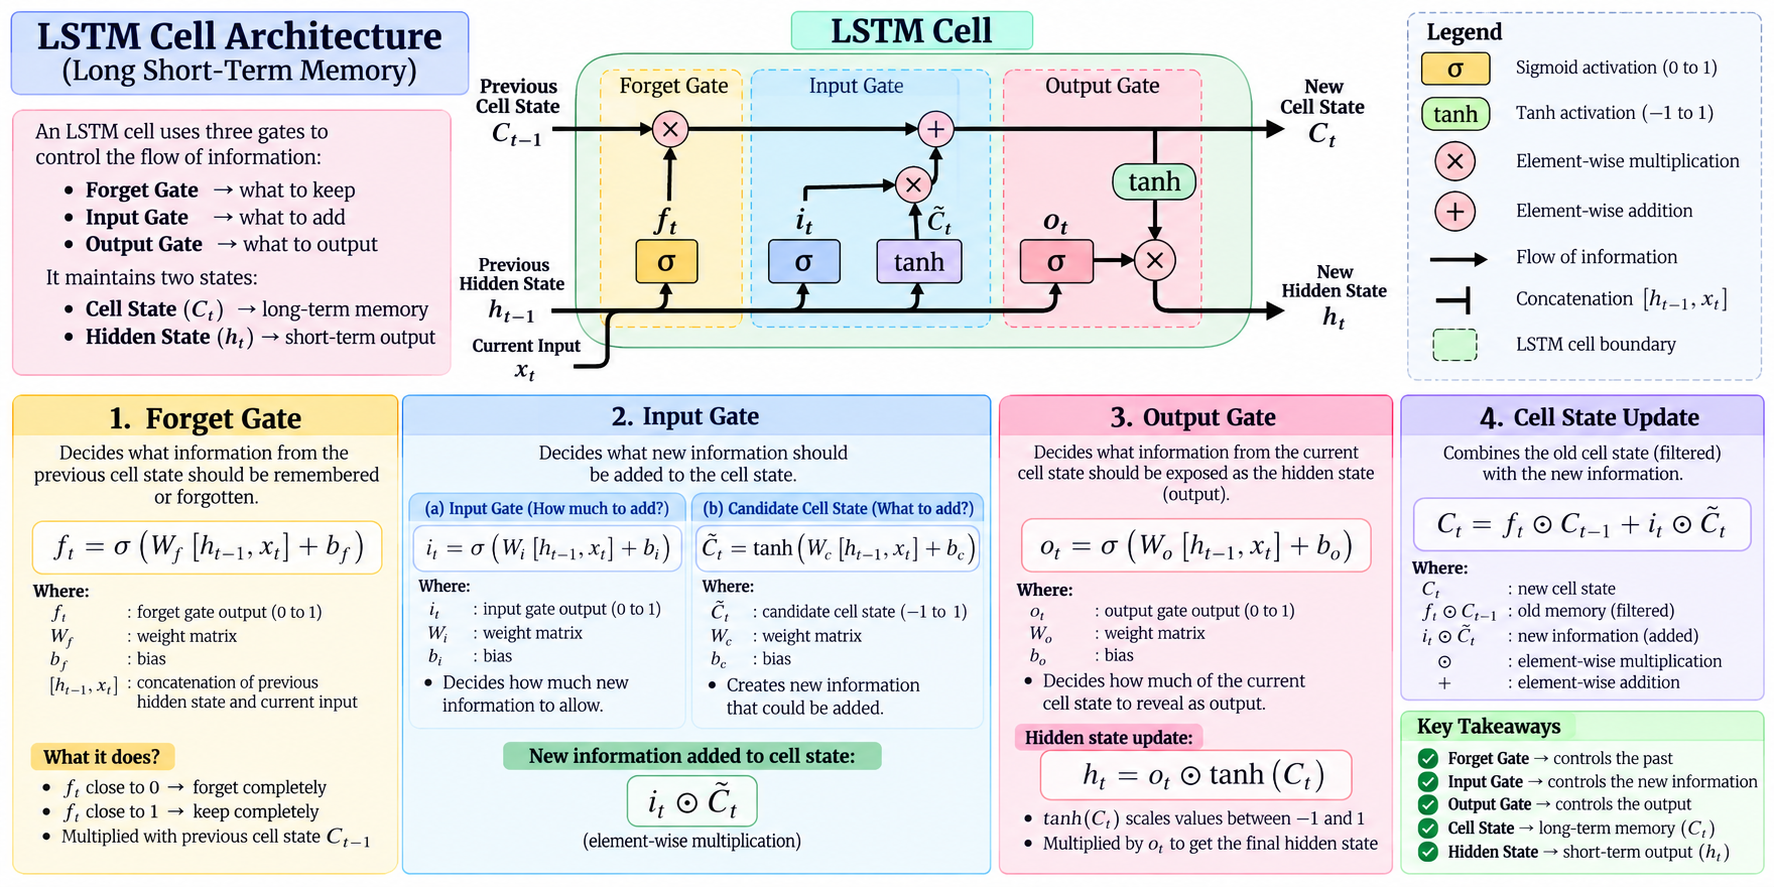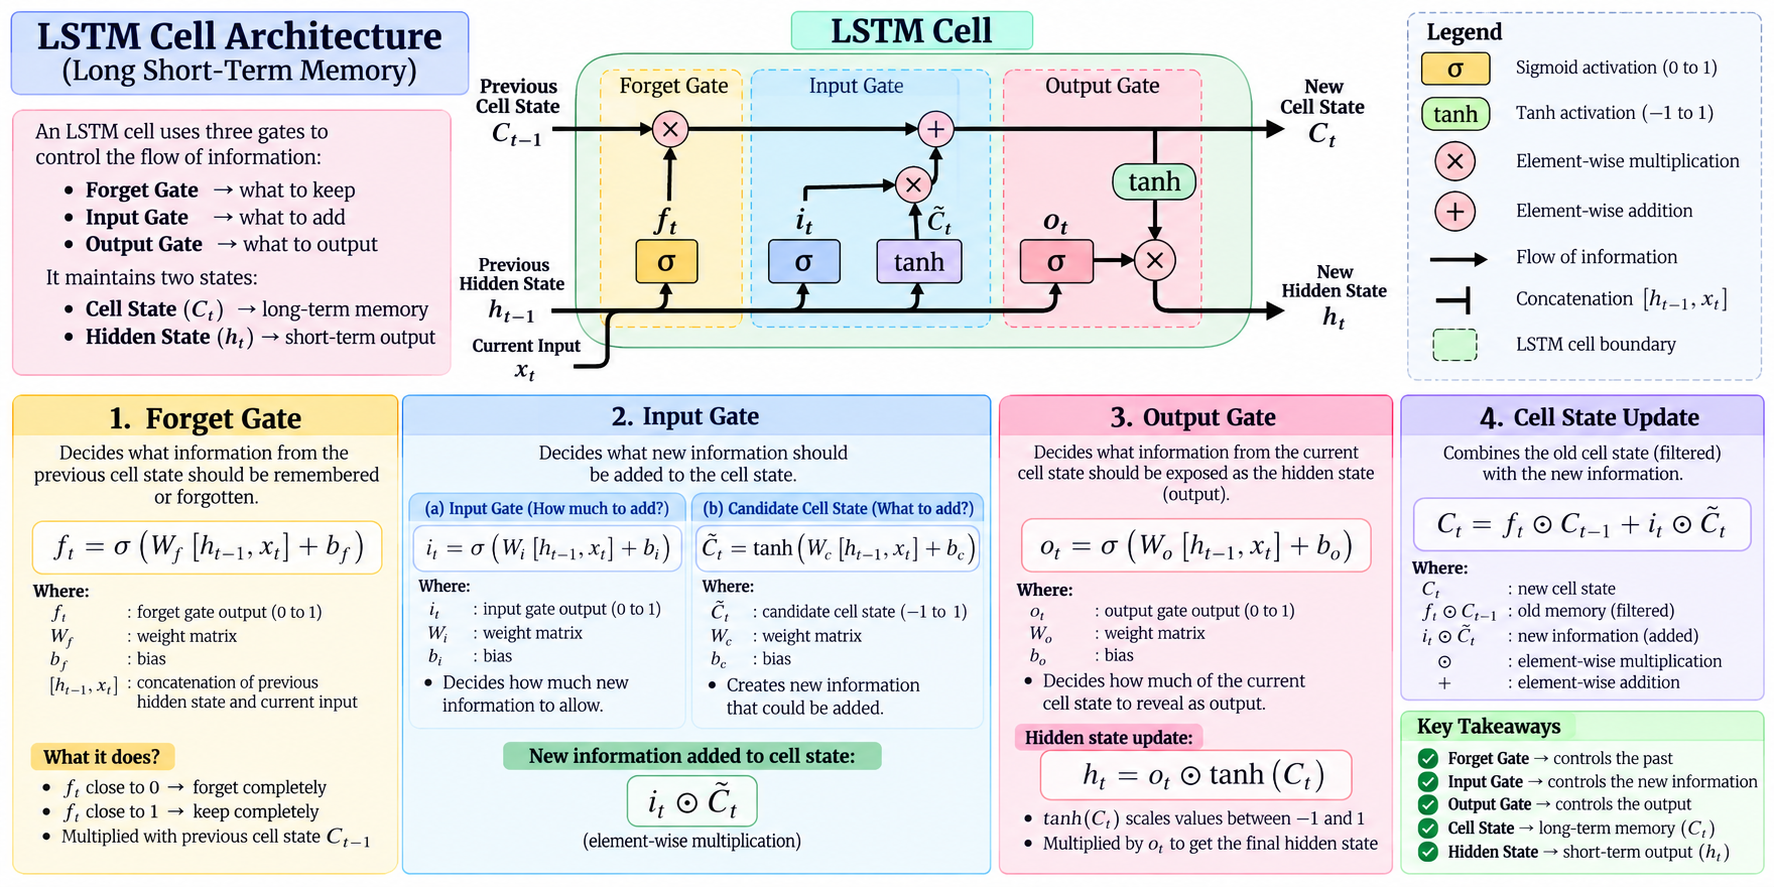

# <span style="color:#1B4F72;">Advantages, Disadvantages & Limitations of LSTM</span>

## <span style="color:#27AE60;">Advantages of LSTM</span>

### <span style="color:#2980B9;">1. Handles Long-Term Dependencies</span>

LSTM can retain important information for **long periods** using its cell state and gates.

### <span style="color:#8E44AD;">2. Reduces Vanishing Gradient Problem</span>

The **cell state and gating mechanism** help gradients flow through many time steps more effectively than a basic RNN.

### <span style="color:#16A085;">3. Selective Memory</span>

LSTM can **forget, keep, and add information** using its three gates.

### <span style="color:#D35400;">4. Handles Sequential Data</span>

LSTM is useful for data where **order and context matter**, such as text, speech, and time-series data.

### <span style="color:#7D3C98;">5. Better Context Understanding</span>

It can use information from previous time steps to make better predictions at the current time step.

---

## <span style="color:#C0392B;">Disadvantages of LSTM</span>

### <span style="color:#2980B9;">1. Computationally Expensive</span>

LSTM has **multiple gates and parameters**, making it more computationally expensive than a basic RNN.

### <span style="color:#8E44AD;">2. Slow Training</span>

Like RNNs, LSTMs process sequences **step-by-step**, which limits parallelization and can make training slower.

### <span style="color:#16A085;">3. More Complex Architecture</span>

The **cell state, hidden state, and three gates** make LSTM more difficult to understand and implement than a simple RNN.

### <span style="color:#D35400;">4. More Memory Usage</span>

LSTM needs to maintain additional states and gate computations during training, increasing **memory requirements**.

---

## <span style="color:#C0392B;">Limitations of LSTM</span>

- **Very long sequences:** LSTM can handle long-term dependencies better than RNNs, but extremely long sequences can still be difficult and expensive to process.
- **Large datasets:** Training LSTMs on very large datasets can require significant **time and computational resources**.
- **Parallelization:** Sequential processing makes LSTMs less parallelizable than **Transformers**.
- **Complexity:** Choosing suitable **hidden size, number of layers, dropout, and other hyperparameters** can require experimentation.
- **Transformers:** For many modern NLP tasks, **Transformer architectures** are preferred because they can process sequence information more efficiently in parallel.

> **LSTM = Better Long-Term Memory than RNN + More Computation and Complexity**

<h2 style="
background: linear-gradient(135deg, #E8F8F5, #A3E4D7, #D1F2EB);
color: #0E6251;
padding: 14px 20px;
border-left: 6px solid #16A085;
border-radius: 10px;
font-weight: 800;
box-shadow: 0 4px 12px rgba(22,160,133,0.2);
">
GRU — Gated Recurrent Unit
</h2>

# <span style="color:#1B4F72;">GRU — Gated Recurrent Unit</span>

LSTM has **3 gates**, whereas GRU has **2 gates**.

| LSTM | GRU |
|---|---|
| 3 Gates | 2 Gates |
| Forget Gate | Reset Gate |
| Input Gate | Update Gate |
| Output Gate | — |
| Cell State + Hidden State | Hidden State |

### <span style="color:#2980B9;">Does GRU Have Long-Term + Short-Term Memory?</span>

Conceptually, **GRU can preserve information over both short and long time spans**, but its architecture is different from LSTM.

Unlike LSTM, GRU **does not have a separate cell state (Cₜ)**.

Instead, GRU uses **one hidden state (Hₜ)** to carry information through the sequence.

```text
LSTM:
Xₜ + Hₜ₋₁ + Cₜ₋₁
          ↓
      3 Gates
          ↓
     Hₜ + Cₜ


GRU:
Xₜ + Hₜ₋₁
      ↓
   2 Gates
      ↓
     Hₜ
```

> **LSTM → Separate Cell State + Hidden State**  
> **GRU → Single Hidden State that carries the information**

# <span style="color:#1B4F72;">GRU Gates</span>

<b>GRU has only <span style="color:#C0392B;">2 gates</span>:</b>

### <span style="color:#8E44AD;">1. r<sub>t</sub> — Reset Gate</span>

Controls **how much information from the previous hidden state** should be used when creating the candidate hidden state.

### <span style="color:#2980B9;">2. z<sub>t</sub> — Update Gate</span>

Controls **how much of the previous hidden state is kept** and how much new information is added.

> **Important:** In GRU, **z<sub>t</sub> is called the Update Gate, not the Output Gate.**
>
> **Reset Gate → r<sub>t</sub>**  
> **Update Gate → z<sub>t</sub>**


In reset gate we calculate rt and in update gate we calculate zt

<mark> Both gates work together 

# <span style="color:#1B4F72;">GRU — Gated Recurrent Unit</span>

## <span style="color:#2980B9;">GRU Equations</span>

$$
z_t = \sigma\left(W_z \cdot [h_{t-1},x_t]\right)
$$

$$
r_t = \sigma\left(W_r \cdot [h_{t-1},x_t]\right)
$$

$$
\tilde{h}_t = \tanh\left(W \cdot [r_t * h_{t-1},x_t]\right)
$$

$$
h_t = (1-z_t)*h_{t-1}+z_t*\tilde{h}_t
$$

---

## <span style="color:#8E44AD;">Meaning of Variables</span>

| Symbol | Meaning |
|---|---|
| **h<sub>t-1</sub>** | Previous Hidden State |
| **x<sub>t</sub>** | Current Input |
| **z<sub>t</sub>** | Update Gate |
| **r<sub>t</sub>** | Reset Gate |
| **h̃<sub>t</sub>** | Candidate Hidden State |
| **h<sub>t</sub>** | Current Hidden State |

### <span style="color:#16A085;">Core Flow</span>

```text
Previous Hidden State + Current Input
                ↓
        ┌───────┴───────┐
        ↓               ↓
   Update Gate      Reset Gate
        ↓               ↓
        └───────┬───────┘
                ↓
      Candidate Hidden State
                ↓
       Current Hidden State
```

> **GRU uses two gates:**  
> **Update Gate → decides how much previous information to keep**  
> **Reset Gate → decides how much previous information to ignore**

## <span style="color:#1B4F72;">How GRU Works</span>

### <span style="color:#27AE60;">Step 1 — Create New Information</span>

GRU creates **new information** from the current word/input.

```text
Current Input (xₜ)
      ↓
Create New Information
```

### <span style="color:#2980B9;">Step 2 — Mix with Old Memory</span>

The newly created information is **mixed with the old memory** (previous hidden state).

```text
New Information + Old Memory
            ↓
           Mix
```

### <span style="color:#8E44AD;">Step 3 — Decide the Mixing Ratio</span>

The **Update Gate (zₜ)** decides how much **old memory** and how much **new information** should be used.

```text
Old Memory ───────┐
                  ├──→ Mixing → New Hidden State (hₜ)
New Information ──┘
           ↑
      Update Gate (zₜ)
```

> **Update Gate → Decides the mixing ratio between old memory and new information.**

# <span style="color:#1B4F72;">Advantages & Disadvantages of GRU</span>

## <span style="color:#27AE60;">Advantages of GRU</span>

### <span style="color:#2980B9;">1. Simpler Architecture</span>

GRU has only **2 gates** and does not have a separate cell state, making it simpler than LSTM.

### <span style="color:#8E44AD;">2. Faster Training</span>

Because GRU has **fewer gates and parameters**, it generally requires less computation and can train faster than LSTM.

### <span style="color:#16A085;">3. Handles Long-Term Dependencies</span>

The gating mechanism helps GRU **retain important information** over multiple time steps.

### <span style="color:#D35400;">4. Lower Memory Usage</span>

GRU maintains only a **hidden state** instead of separate hidden and cell states, reducing memory requirements.

---

## <span style="color:#C0392B;">Disadvantages of GRU</span>

### <span style="color:#2980B9;">1. Less Control Over Memory</span>

Compared with LSTM, GRU has a simpler gating mechanism, so it provides **less explicit control** over long-term memory.

### <span style="color:#8E44AD;">2. May Perform Differently on Complex Sequences</span>

For some tasks involving **very complex or long-term dependencies**, LSTM may capture certain patterns differently because of its separate cell state and three gates.

### <span style="color:#16A085;">3. Still Sequential</span>

Like RNN and LSTM, GRU processes sequence elements **step-by-step**, which limits parallelization during training.

### <span style="color:#D35400;">4. Hyperparameter Tuning</span>

GRU still requires suitable choices for parameters such as **hidden size, number of layers, learning rate, and dropout**.

> **GRU = Simpler + Faster + Less Memory**  
> **But = Less explicit memory control + Still sequential**

# <span style="color:#1B4F72;">Why GRU Instead of LSTM?</span>

### <span style="color:#2980B9;">1. Simpler Architecture</span>

GRU has **2 gates** and only one hidden state, while LSTM has **3 gates + cell state + hidden state**.

> **GRU → Less complexity**

### <span style="color:#27AE60;">2. Faster Training</span>

GRU has **fewer parameters and computations**, so it can generally train faster than LSTM.

### <span style="color:#8E44AD;">3. Lower Memory Usage</span>

GRU does not maintain a separate **cell state**, so it generally requires less memory.

### <span style="color:#D35400;">4. Good for Smaller Datasets</span>

Its simpler architecture can be useful when you have **limited data or computational resources**.

---

# <span style="color:#1B4F72;">When to Use GRU?</span>

Use **GRU** when:

- You want **faster training**.
- You have **limited computational resources**.
- You want a **simpler model**.
- Your sequence problem does not require highly complex memory handling.
- You want to experiment with a recurrent architecture before using a more complex LSTM.

> **GRU → Simpler + Faster + Lower Memory**

---

# <span style="color:#1B4F72;">When to Use LSTM?</span>

Use **LSTM** when:

- The task involves **complex long-term dependencies**.
- You want more **explicit control over memory** through the cell state and gates.
- The sequence contains important information that may need to be preserved for a long time.
- You can afford **higher computational cost**.

> **LSTM → More Complex + More Memory Control**

---

## <span style="color:#8E44AD;">Quick Comparison</span>

| Feature | GRU | LSTM |
|---|---|---|
| Gates | **2** | **3** |
| Cell State | No | Yes |
| Hidden State | Yes | Yes |
| Parameters | Fewer | More |
| Training | Generally faster | Generally slower |
| Memory Usage | Lower | Higher |
| Architecture | Simpler | More complex |
| Long-term dependencies | Handles them | Handles them |

> **Important:** There is no universal rule that GRU is always better or LSTM is always better. The best choice depends on the **dataset, sequence complexity, computational resources, and experimental results**.

In [ ]:
#now theory is complete now we will implement lstm gru and rnn as well 




<h2 style="
background: linear-gradient(135deg, #E8F8F5, #A3E4D7, #D1F2EB);
color: #0E6251;
padding: 14px 20px;
border-left: 6px solid #16A085;
border-radius: 10px;
font-weight: 800;
box-shadow: 0 4px 12px rgba(22,160,133,0.2);
">
Project : Sentence Completion Bot
</h2>